PIFOCast - Training and evaluation
===================================
Train the GNN model with JAX/Flax and run an auto-regressive test.

In [6]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
import orbax.checkpoint
from flax.training import train_state

import importlib

import pifocast
importlib.reload(pifocast)

from pifocast import LatLonGrid, PifoModel, pifoGridGenerator, getGraphExample

### Configuration

In [7]:
NUM_ITERATIONS = 10
BATCH_SIZE = 2
LEARNING_RATE = 1e-3
DECAY_STEPS = 1500
DECAY_RATE = 0.1

NUM_MESSAGE_PASSING_STEPS = 4
NUM_MLP_HIDDEN_LAYERS = 1
MLP_HIDDEN_SIZE = 8
LATENT_SIZE = 8
OUTPUT_SIZE = 3

NUM_TRAIN_EXAMPLES = 300
NUM_VAL_EXAMPLES = 66
TRAIN_PER_MONTH = 25

grid = LatLonGrid("dataset/202504.grib", 4)

static_files = ["edge_features.npy", "pos_features.npy",
                "sources.npy", "targets.npy"]
edge_features = np.load("dataset/edge_features.npy")
pos_features = np.load("dataset/pos_features.npy")
sources = np.load("dataset/sources.npy")
targets = np.load("dataset/targets.npy")

print(f"Grid: {grid.NLat}x{grid.NLon}, {grid.NNodes} nodes, {grid.NEdges} edges")
print(f"edge_features: {edge_features.shape}, pos_features: {pos_features.shape}")

Grid: 181x360, 65160 nodes, 257760 edges
edge_features: (257760, 3), pos_features: (65160, 3)


### Load pre-computed .npy cache
All node_features and labels are pre-computed once by `pifocast-dataset.ipynb`.
We split each month: first 25 → train, rest → validation.

In [8]:
trainFiles = [
    "202401", "202402", "202403",
    "202404", "202405", "202406",
    "202407", "202408", "202409",
    "202410", "202411", "202412"
]

train_nf, train_labels = [], []
val_nf, val_labels = [], []

for month in trainFiles:
    nf = np.load(f"dataset/{month}_nf.npy")
    lb = np.load(f"dataset/{month}_labels.npy")
    n_total = nf.shape[0]
    n_train = min(TRAIN_PER_MONTH, n_total)
    train_nf.append(nf[:n_train])
    train_labels.append(lb[:n_train])
    val_nf.append(nf[n_train:])
    val_labels.append(lb[n_train:])
    print(f"{month}: {n_total} examples ({n_train} train, {n_total - n_train} val)")

train_nf = np.concatenate(train_nf, axis=0)
train_labels = np.concatenate(train_labels, axis=0)
val_nf = np.concatenate(val_nf, axis=0)
val_labels = np.concatenate(val_labels, axis=0)

print(f"\nTrain: {train_nf.shape}, {train_labels.shape}")
print(f"Val:   {val_nf.shape}, {val_labels.shape}")

202401: 31 examples (25 train, 6 val)
202402: 29 examples (25 train, 4 val)
202403: 31 examples (25 train, 6 val)
202404: 30 examples (25 train, 5 val)
202405: 31 examples (25 train, 6 val)
202406: 30 examples (25 train, 5 val)
202407: 31 examples (25 train, 6 val)
202408: 31 examples (25 train, 6 val)
202409: 30 examples (25 train, 5 val)
202410: 31 examples (25 train, 6 val)
202411: 30 examples (25 train, 5 val)
202412: 31 examples (25 train, 6 val)

Train: (300, 65160, 6), (300, 65160, 3)
Val:   (66, 65160, 6), (66, 65160, 3)


### Model initialization

In [9]:
rng = jax.random.PRNGKey(0)

model = PifoModel(
    latent_size=LATENT_SIZE,
    mlp_hidden_size=MLP_HIDDEN_SIZE,
    num_message_passing_steps=NUM_MESSAGE_PASSING_STEPS,
    num_mlp_hidden_layers=NUM_MLP_HIDDEN_LAYERS,
    output_size=OUTPUT_SIZE,
    use_layer_norm=True
)

dummy_nf = jnp.ones((grid.NNodes, 6))
dummy_ef = jnp.array(edge_features)
dummy_src = jnp.array(sources)
dummy_tgt = jnp.array(targets)

params = model.init(rng, dummy_nf, dummy_ef, dummy_src, dummy_tgt)
total = sum(p.size for p in jax.tree_util.tree_leaves(params))
print(f"Total params: {total}")

Total params: 2566


### Training loop

In [10]:
lr_schedule = optax.exponential_decay(
    init_value=LEARNING_RATE,
    transition_steps=DECAY_STEPS,
    decay_rate=DECAY_RATE
)
tx = optax.adam(learning_rate=lr_schedule, b1=0.9, b2=0.95)
state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

ef = jnp.array(edge_features)
src = jnp.array(sources)
tgt = jnp.array(targets)

@jax.jit
def train_step(state, nf_batch, ef, src, tgt, labels_batch):
    def loss_fn(p):
        pred = jax.vmap(lambda nf: state.apply_fn(p, nf, ef, src, tgt))(nf_batch)
        return jnp.mean((pred - labels_batch) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

@jax.jit
def eval_step(state, nf_batch, ef, src, tgt, labels_batch):
    pred = jax.vmap(lambda nf: state.apply_fn(state.params, nf, ef, src, tgt))(nf_batch)
    loss = jnp.mean((pred - labels_batch) ** 2)
    return loss, jnp.sqrt(loss)

steps_per_epoch = NUM_TRAIN_EXAMPLES // BATCH_SIZE
val_steps = NUM_VAL_EXAMPLES // BATCH_SIZE

losses, val_losses = [], []

for epoch in range(NUM_ITERATIONS):
    t0 = time.time()

    perm = np.random.permutation(NUM_TRAIN_EXAMPLES)
    ep_loss = 0.0
    for step in range(steps_per_epoch):
        idx = perm[step * BATCH_SIZE : (step + 1) * BATCH_SIZE]
        nf_batch = jnp.array(train_nf[idx])
        lb_batch = jnp.array(train_labels[idx])
        state, loss = train_step(state, nf_batch, ef, src, tgt, lb_batch)
        ep_loss += loss

    vl = 0.0
    for step in range(val_steps):
        idx = slice(step * BATCH_SIZE, (step + 1) * BATCH_SIZE)
        nf_batch = jnp.array(val_nf[idx])
        lb_batch = jnp.array(val_labels[idx])
        l, r = eval_step(state, nf_batch, ef, src, tgt, lb_batch)
        vl += l

    ep_loss /= steps_per_epoch
    vl /= val_steps
    losses.append(ep_loss)
    val_losses.append(vl)

    dt = time.time() - t0
    print(f"Epoch {epoch+1}/{NUM_ITERATIONS}  loss: {ep_loss:.6f}  val_loss: {vl:.6f}  ({dt:.0f}s)")

Epoch 1/10  loss: 0.010545  val_loss: 0.001113  (192s)
Epoch 2/10  loss: 0.001091  val_loss: 0.001071  (187s)
Epoch 3/10  loss: 0.001078  val_loss: 0.001070  (179s)
Epoch 4/10  loss: 0.001073  val_loss: 0.001070  (180s)
Epoch 5/10  loss: 0.001071  val_loss: 0.001060  (181s)
Epoch 6/10  loss: 0.001069  val_loss: 0.001060  (179s)
Epoch 7/10  loss: 0.001068  val_loss: 0.001058  (178s)
Epoch 8/10  loss: 0.001067  val_loss: 0.001059  (179s)
Epoch 9/10  loss: 0.001065  val_loss: 0.001057  (183s)
Epoch 10/10  loss: 0.001065  val_loss: 0.001055  (170s)


### Learning curves

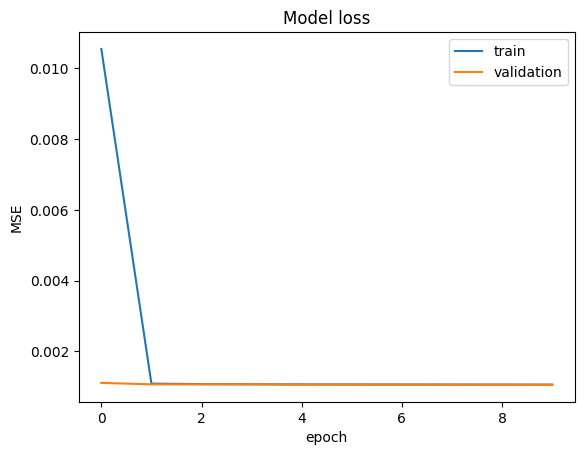

In [11]:
plt.plot(losses, label="train")
plt.plot(val_losses, label="validation")
plt.legend()
plt.title("Model loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.show()

### Save / restore checkpoint

In [13]:
os.makedirs("./pifo_chk", exist_ok=True)
ckpt_path = os.path.abspath("./pifo_chk/final_checkpoint")

checkpointer = orbax.checkpoint.PyTreeCheckpointer()
checkpointer.save(ckpt_path, state)
print(f"Saved to {ckpt_path}")

Saved to /home/nicolas/Projects/pifocast/pifo_chk/final_checkpoint


In [ ]:
# au cas où : checkpoint avec Pickle...
#import pickle                                                                                                                                                                                                                   
#with open("./pifo_chk/params.pkl", "wb") as f:                                                                                                                                                                                  
#    pickle.dump({"params": state.params}, f)                                                                                                                                                                                    
#print("Sauvé !")

In [ ]:
# Restore (uncomment to use)
# checkpointer = orbax.checkpoint.PyTreeCheckpointer()
# restored = checkpointer.restore(ckpt_path)
# state = restored
# print(f"Restored from {ckpt_path}")

### Auto-regressive test

In [ ]:
os.makedirs("images", exist_ok=True)

def plot_field(Y, width, height, title="", fname="plot"):
    img = Y.reshape(height, width)
    plt.imshow(img, interpolation='none')
    plt.title(title)
    plt.colorbar()
    plt.savefig(f"images/run_20260628_{fname}.png", bbox_inches="tight")
    plt.show()

nf, ef, src, tgt, X = getGraphExample(grid)
nf = jnp.array(nf)
X = np.array(X)

Y = model.apply(state.params, nf, jnp.array(ef),
                jnp.array(src), jnp.array(tgt))
Y = np.array(Y)

plot_field(X[:, 0], grid.NLon, grid.NLat, "Ground truth Z", "gt_z")
plot_field(Y[:, 0], grid.NLon, grid.NLat, "Predicted Z (step 1)", "pred_z_step_1")

for i in range(2, 20):
    nf = np.concatenate([Y, np.array(pos_features)], axis=1)
    Y = model.apply(state.params, jnp.array(nf), jnp.array(ef),
                    jnp.array(src), jnp.array(tgt))
    Y = np.array(Y)
    plot_field(Y[:, 0], grid.NLon, grid.NLat, f"Predicted Z (step {i})", f"pred_z_step_{i}")